# Section 3 — BDC & fund filings: the loan-level layer

Thin driver notebook: all logic lives in `src/edgar/`.

- **Form ADV** (`scrape_adv.py`): 3 dated bulk snapshots (2012/2018/2026) for a real historical manager-count/RAUM trend.
- **Bank-loan fund N-PORT** (`scrape_nport.py`): shares parsing logic with Section 2 via `src/common/nport.py`.
- **BDC Schedules of Investment** (`scrape_bdc_soi.py`): the mission brief's suggested approach (parsing the combined 10-K/10-Q HTML) doesn't work — the SOI isn't in a normal `<table>` there. The real fix: EDGAR's per-statement XBRL-rendered report fragment, reshaped from its long "Investment, Identifier [Axis]" format. 5/8 tracked BDCs parsed successfully this run; failures are logged per-filing, not fatal.
- **Entity resolution** (`analysis_resolution.py`): the match-cascade funnel is itself an exhibit (`viz_funnel.py`).
- **Mark dispersion** (`analysis_mark_dispersion.py`): the signature "one loan, several prices" piece — real cross-filer mark disagreement, coverage today is 2+ filers per issuer (the mission brief's >=3 bar needs more BDCs parsing successfully).

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

from IPython.display import Image, display

from src.edgar import (
    scrape_bdc_soi, scrape_nport, scrape_adv,
    analysis_resolution, analysis_mark_dispersion, analysis_crowding, analysis_terms, analysis_managers,
    viz_dispersion, viz_crowding, viz_terms, viz_funnel,
)

/Users/zinuoshi/clo-atlas/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## Scrape (raw -> interim)

In [2]:
RUN_SCRAPE = False
if RUN_SCRAPE:
    scrape_bdc_soi.run()
    scrape_nport.run()
    scrape_adv.run()

## Analysis (interim -> final)

In [3]:
resolution = analysis_resolution.run()
dispersion = analysis_mark_dispersion.run()
crowding = analysis_crowding.run()
terms = analysis_terms.run()
managers = analysis_managers.run()

maturity date isn't a clean structured field in the BDC SOI XBRL fragment; maturity_wall is empty rather than guessed from free text


## Viz (final -> figures/)

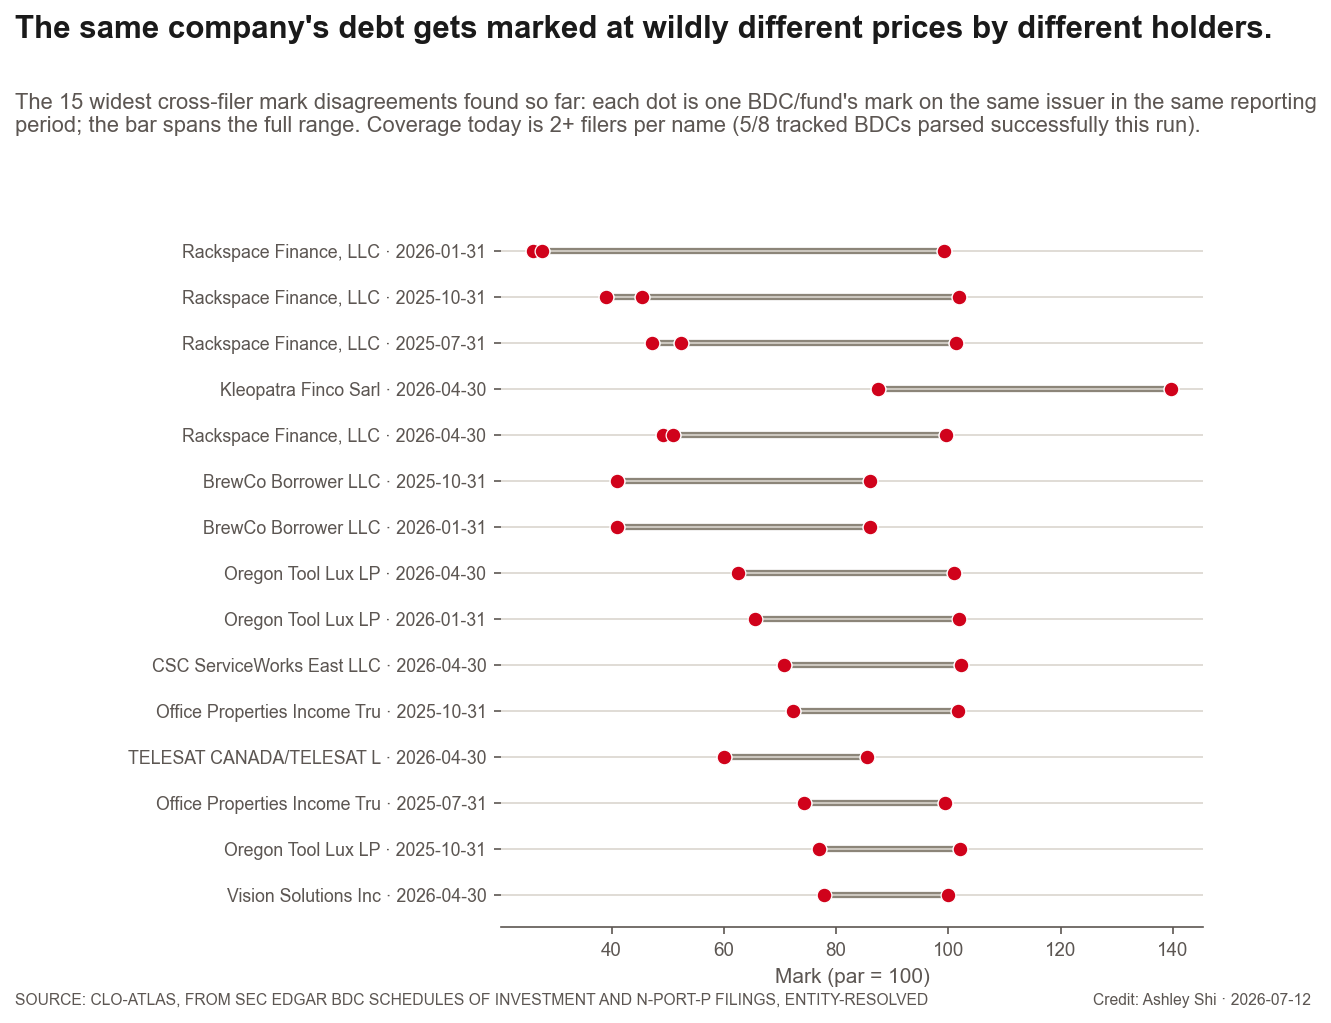

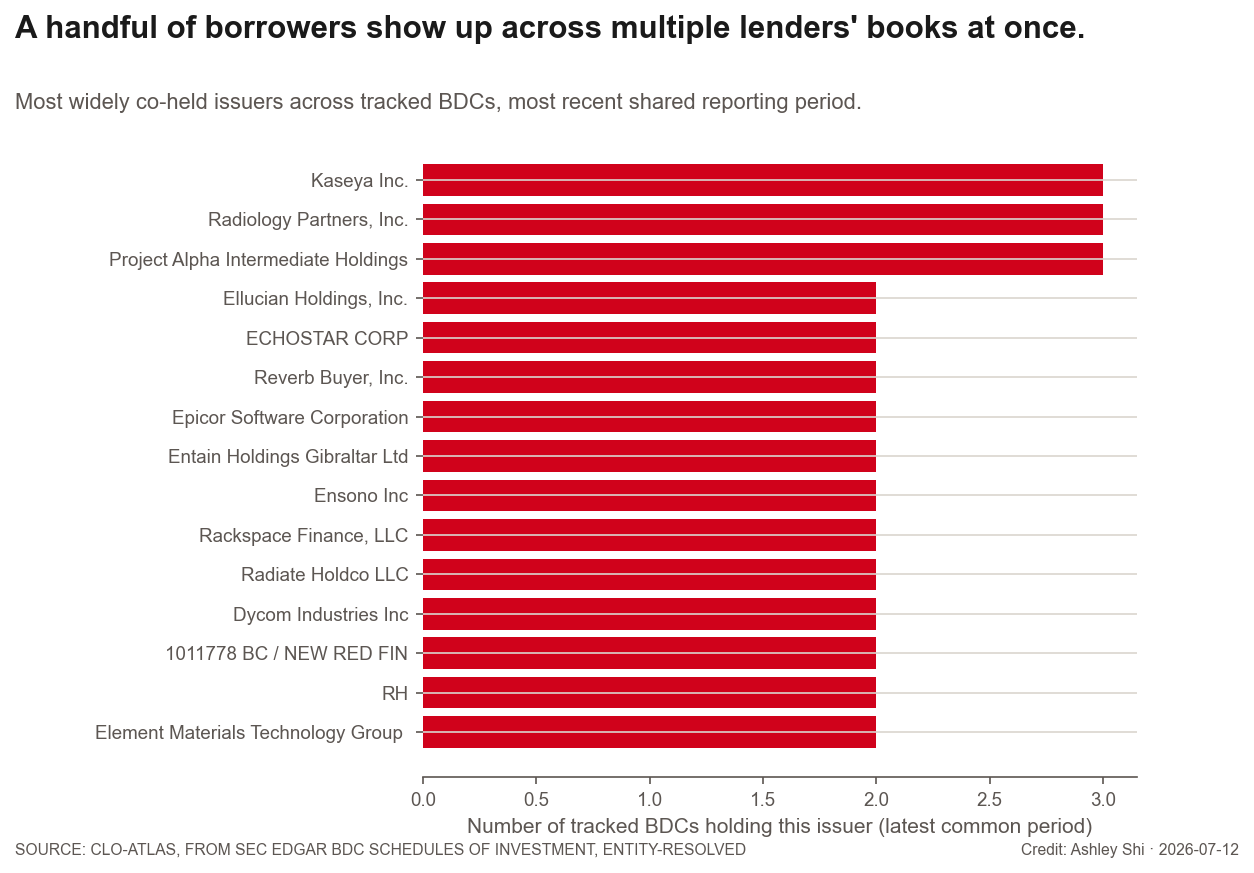

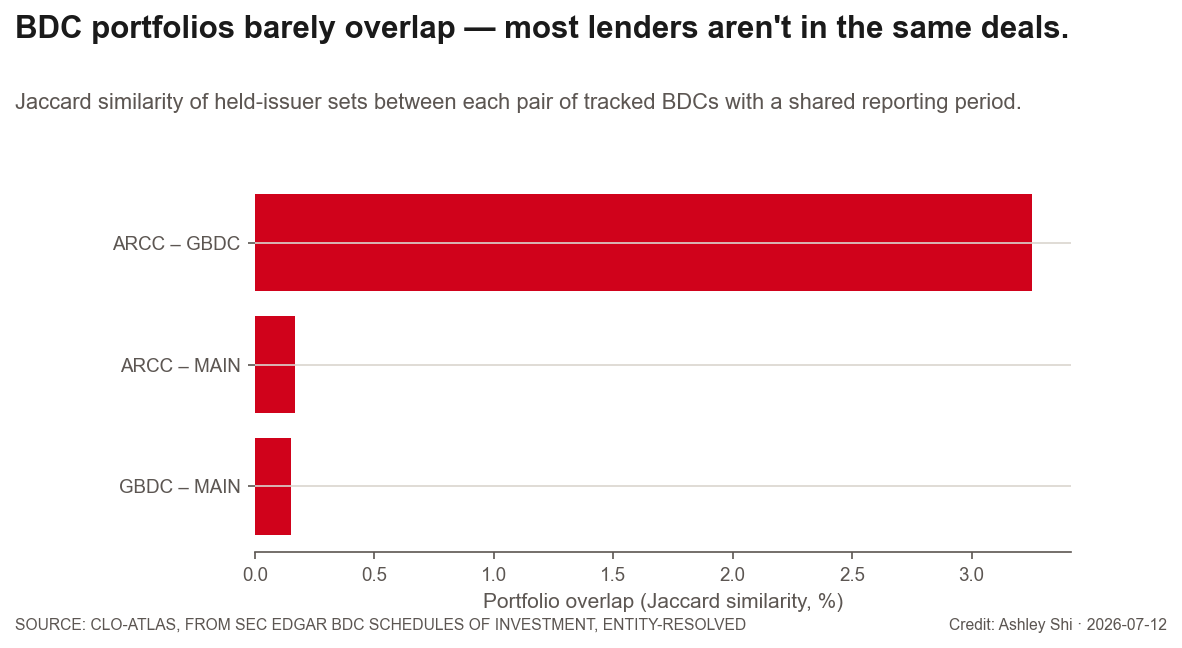

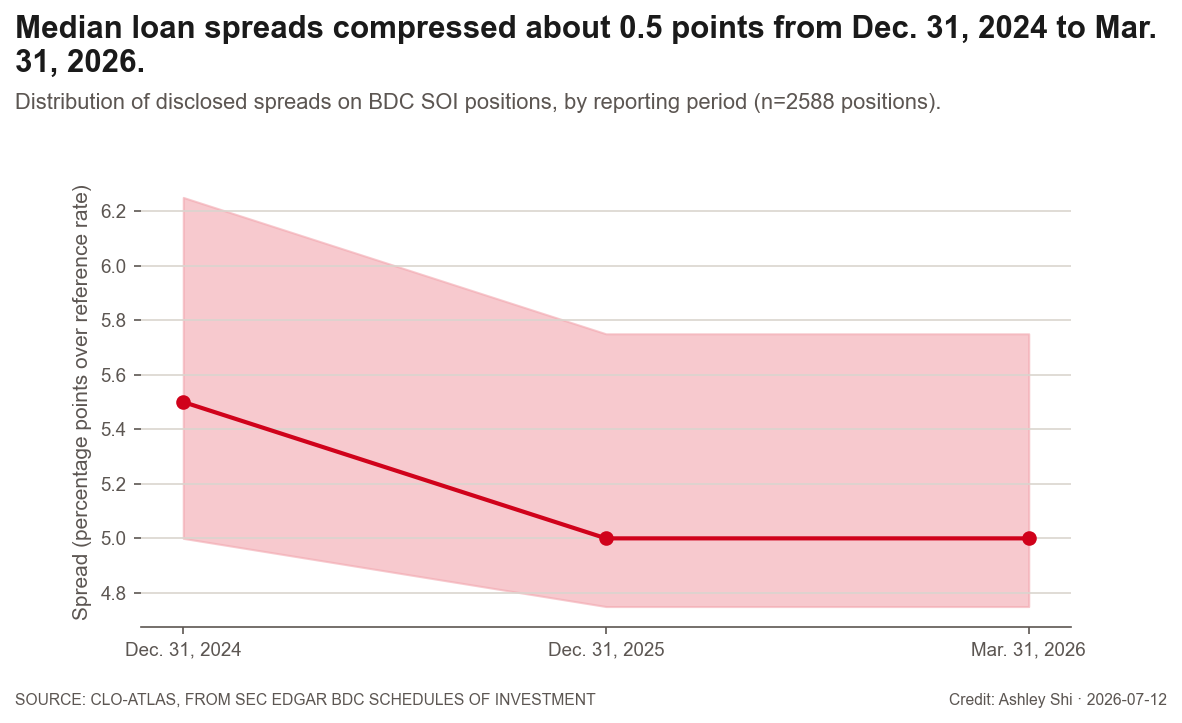

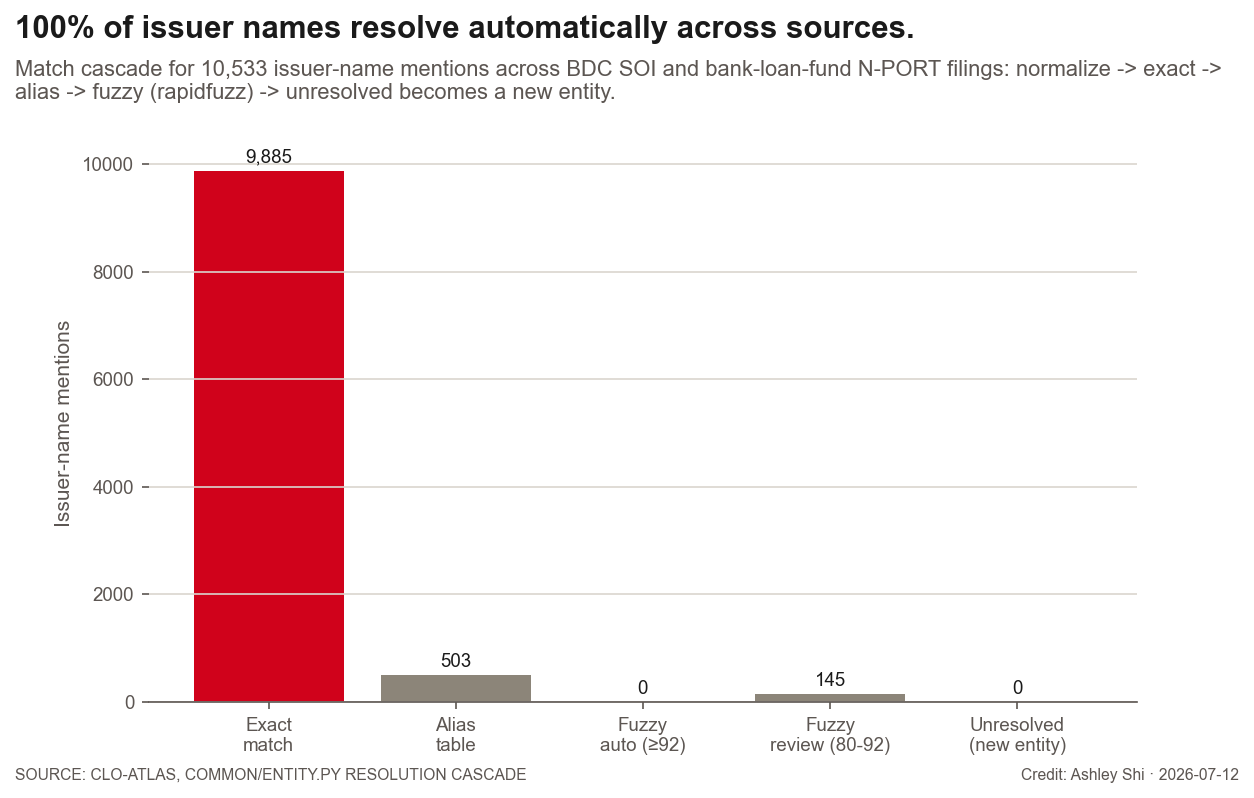

In [4]:
viz_dispersion.run()
viz_crowding.run()
viz_terms.run()
viz_funnel.run()

## Exhibits

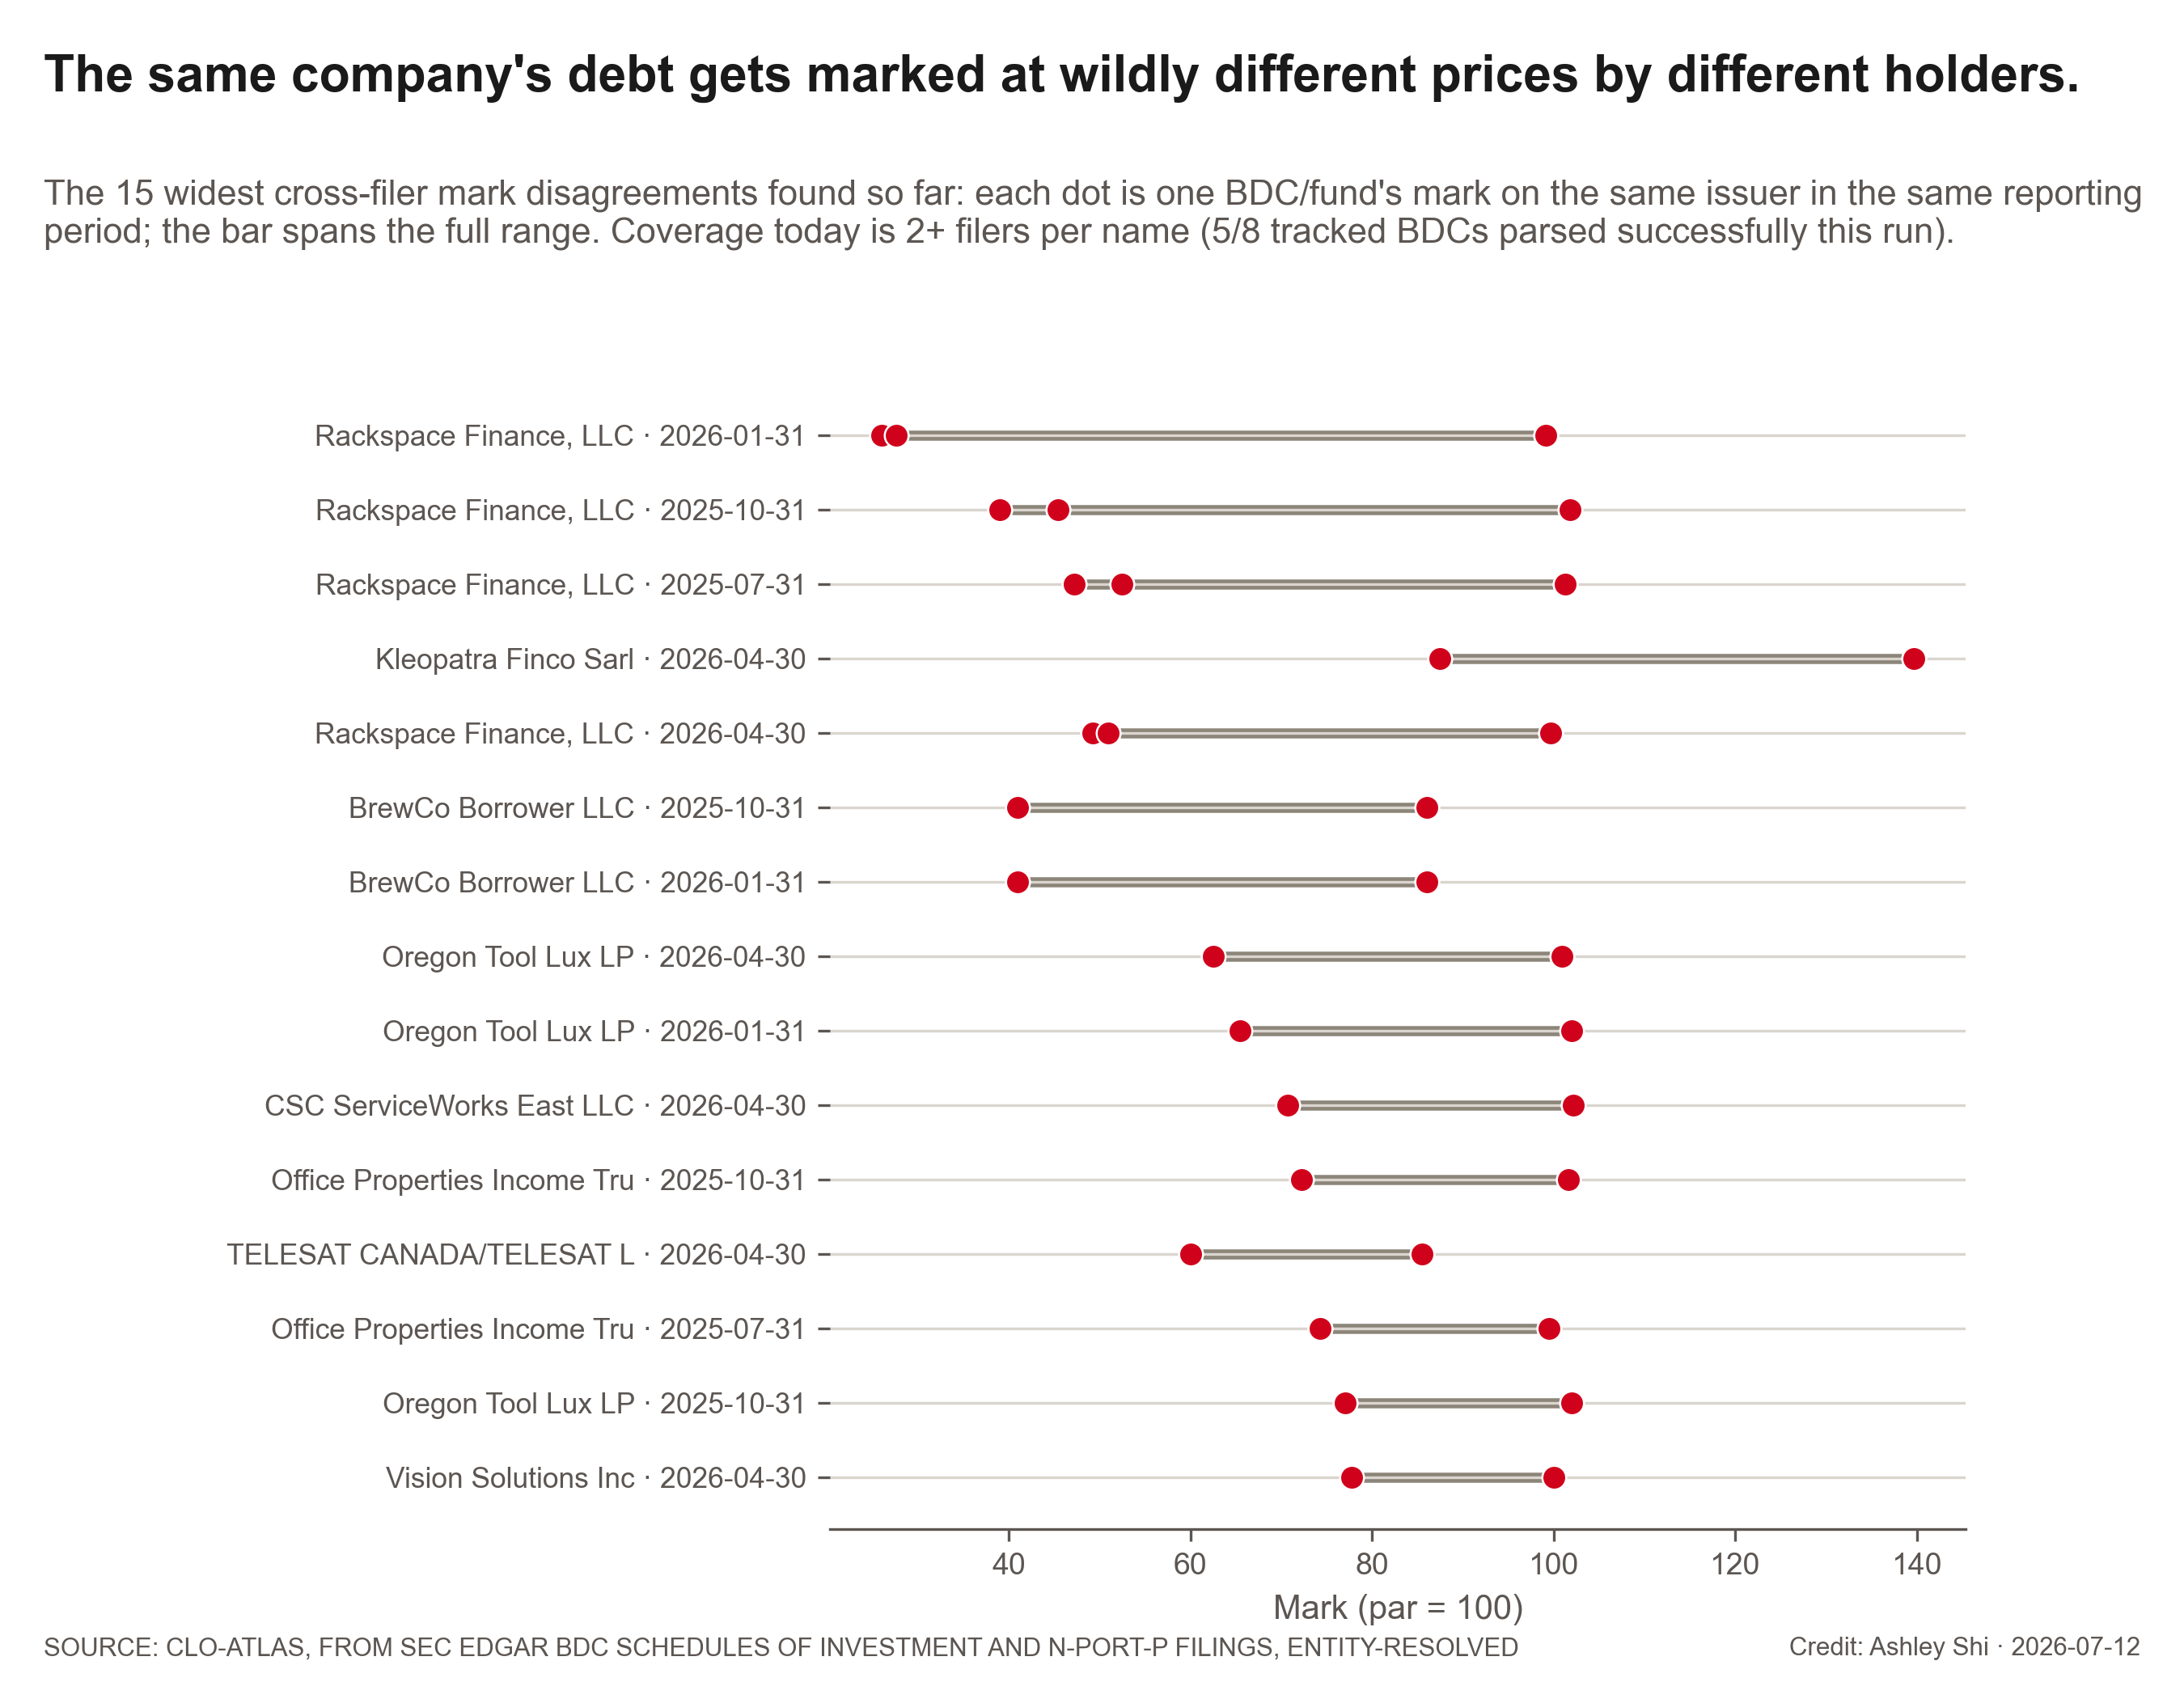

In [5]:
path = pathlib.Path("../figures") / "viz_one_loan_several_prices.png"
if path.exists():
    display(Image(filename=str(path)))
else:
    print(f"[skipped — not generated this run] viz_one_loan_several_prices")

### One loan, several prices

**VERIFIED** — data: SEC EDGAR BDC Schedules of Investment (10-K/10-Q XBRL-rendered
report fragments, `scrape_bdc_soi.py`) and bank-loan closed-end fund N-PORT-P filings
(`scrape_nport.py`), both normalized to a par-100 price convention and merged on the
entity-resolved issuer table (`analysis_resolution.py`, `analysis_mark_dispersion.py`).
Each row is one issuer in one reporting period; each dot is one filer's mark on that
issuer, and the bar spans the full min–max range. The worst case in the data is
Rackspace Finance, LLC — a 73-point gap between the lowest and highest mark filed in
the same quarter (2026-01-31). This is a direct, filing-level demonstration that a
leveraged loan's "price" is an institution's opinion, not an observable market quote —
and CLOs are built entirely out of these same loans, so every tranche NAV and every
overcollateralization test inherits that same disagreement whether or not it's visible
to the CLO investor.


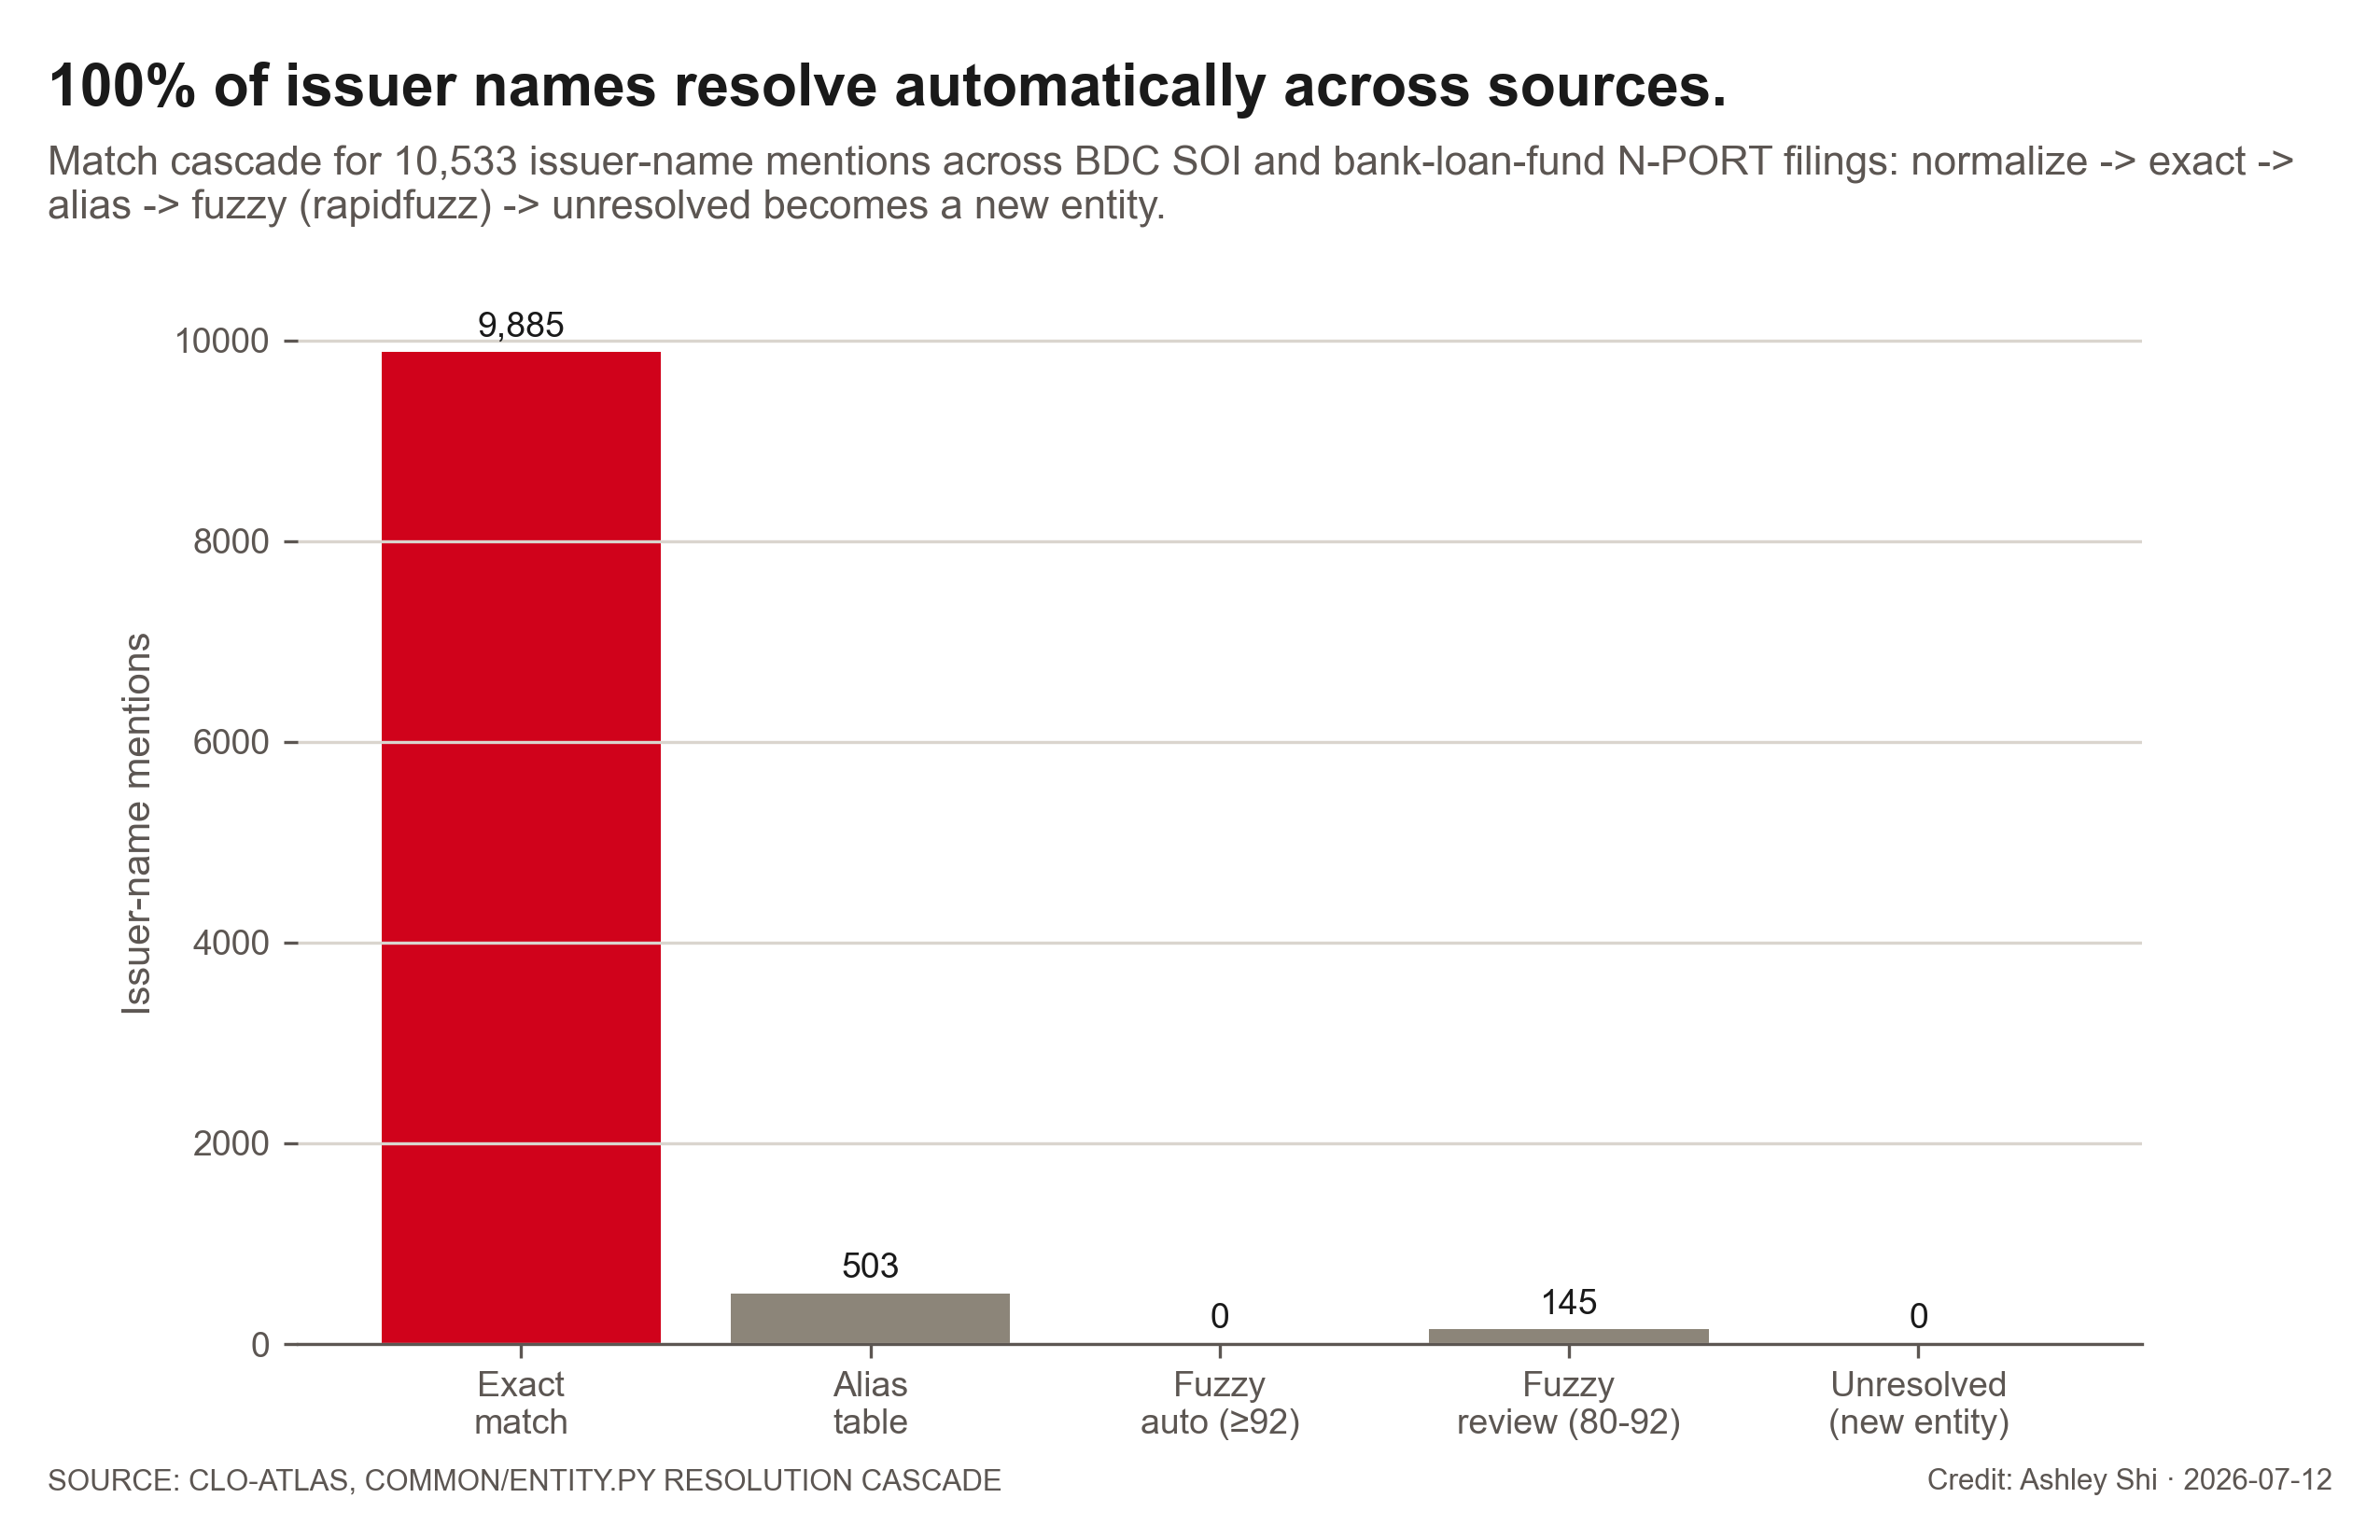

In [6]:
path = pathlib.Path("../figures") / "viz_resolution_funnel.png"
if path.exists():
    display(Image(filename=str(path)))
else:
    print(f"[skipped — not generated this run] viz_resolution_funnel")

### The entity-resolution funnel

**VERIFIED** — data: output of the match cascade in `src/common/entity.py`
(normalize -> exact match -> alias table -> fuzzy match -> unresolved-becomes-new-entity),
run in `analysis_resolution.py` against every issuer-name mention across the tracked
BDC SOI and bank-loan-fund N-PORT filings. The bars show issuer-name mentions by stage:
this run resolved 10,533 mentions, 9,885 by exact string match, 503 through the alias
table, and 145 in the fuzzy-review band — none unresolved. This chart is the plumbing
behind every other exhibit in this section: without reconciling "Rackspace Finance,
LLC" filed one way by one BDC and another way by a bank-loan fund, none of the
crowding, overlap, or dispersion analysis below would be possible — it would just look
like a market of thousands of one-off, un-connected borrowers instead of the same
credits showing up again and again across lenders.


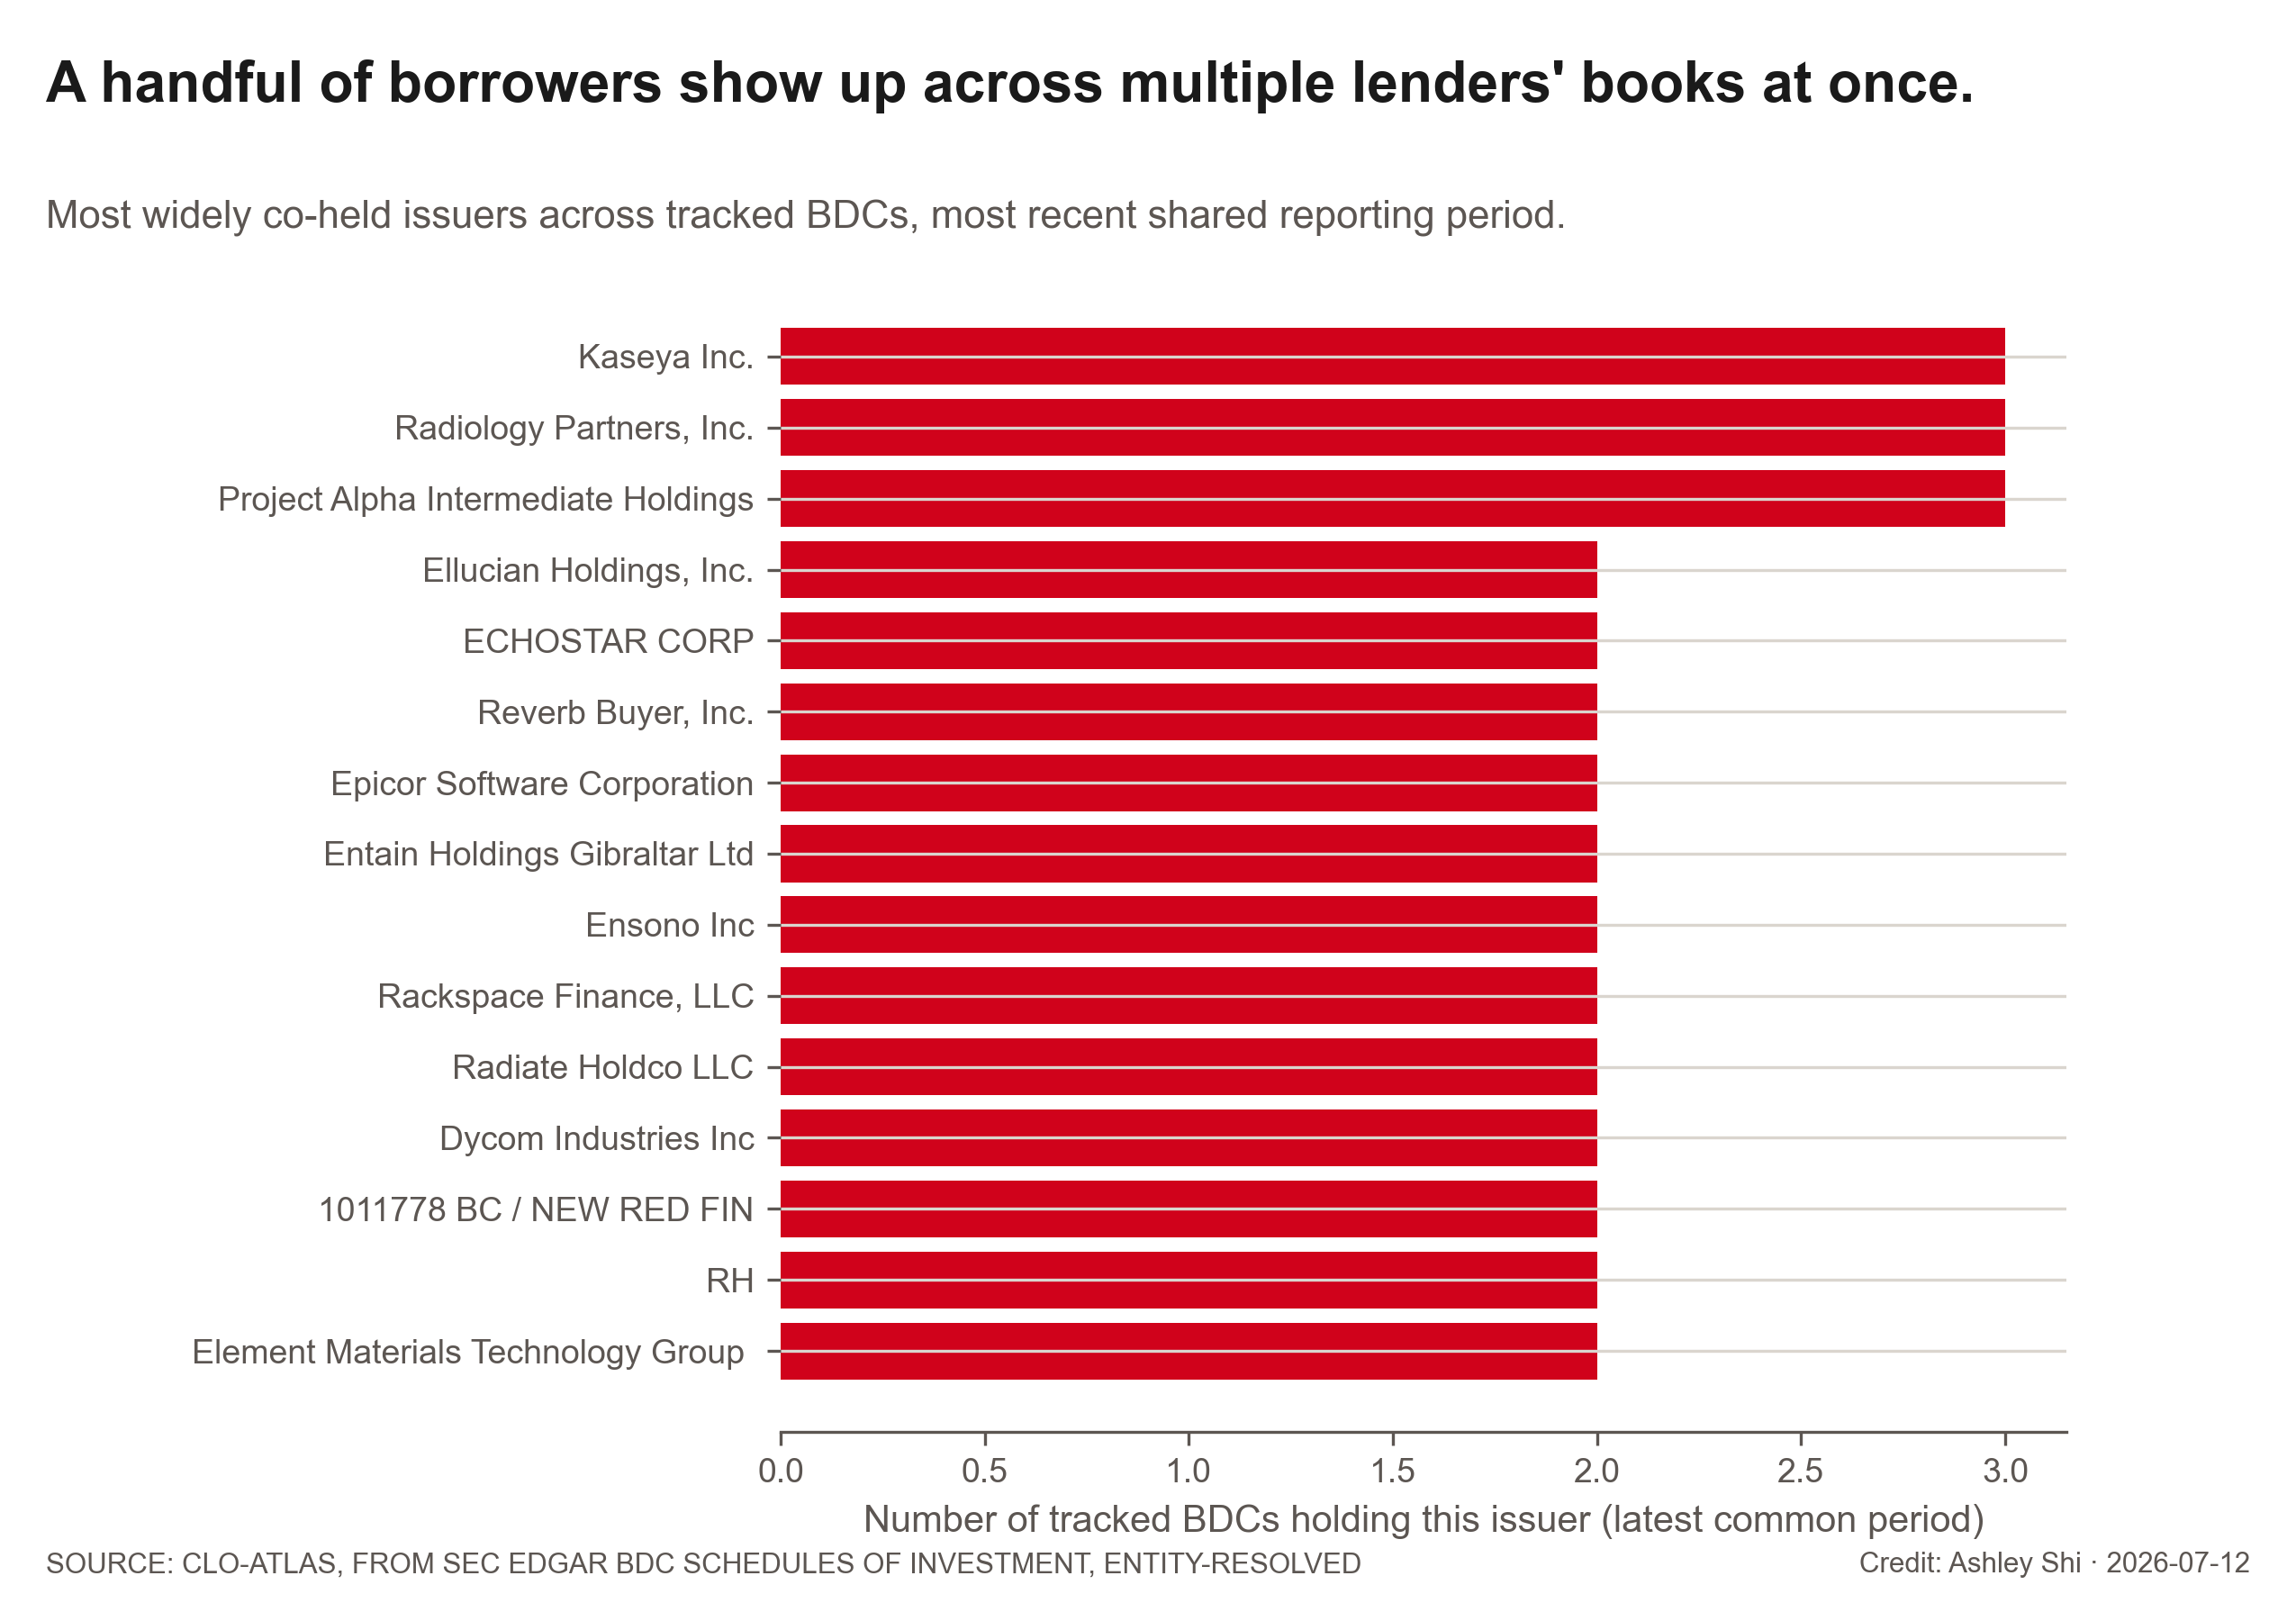

In [7]:
path = pathlib.Path("../figures") / "viz_top_crowded_issuers.png"
if path.exists():
    display(Image(filename=str(path)))
else:
    print(f"[skipped — not generated this run] viz_top_crowded_issuers")

### The most crowded issuers

**VERIFIED** — data: `analysis_crowding.py::top_crowded_issuers()`, from the
entity-resolved issuer table, snapshotted at the latest reporting period shared by
the tracked BDCs (SEC EDGAR BDC Schedules of Investment). Bars show the 15 issuers
held by the most distinct BDCs at once; the x-axis is a headcount of tracked lenders,
topping out at 3 filers (Kaseya Inc., Radiology Partners, Inc., and Project Alpha
Intermediate Holdings, Inc. each show up in three BDCs' books simultaneously). It's a
small, concrete illustration of loan-market concentration: the same underlying credit
risk sits inside multiple lenders' portfolios — and, by extension, inside multiple
CLOs — at the same time, so a single borrower's default doesn't stay contained to one
vehicle.


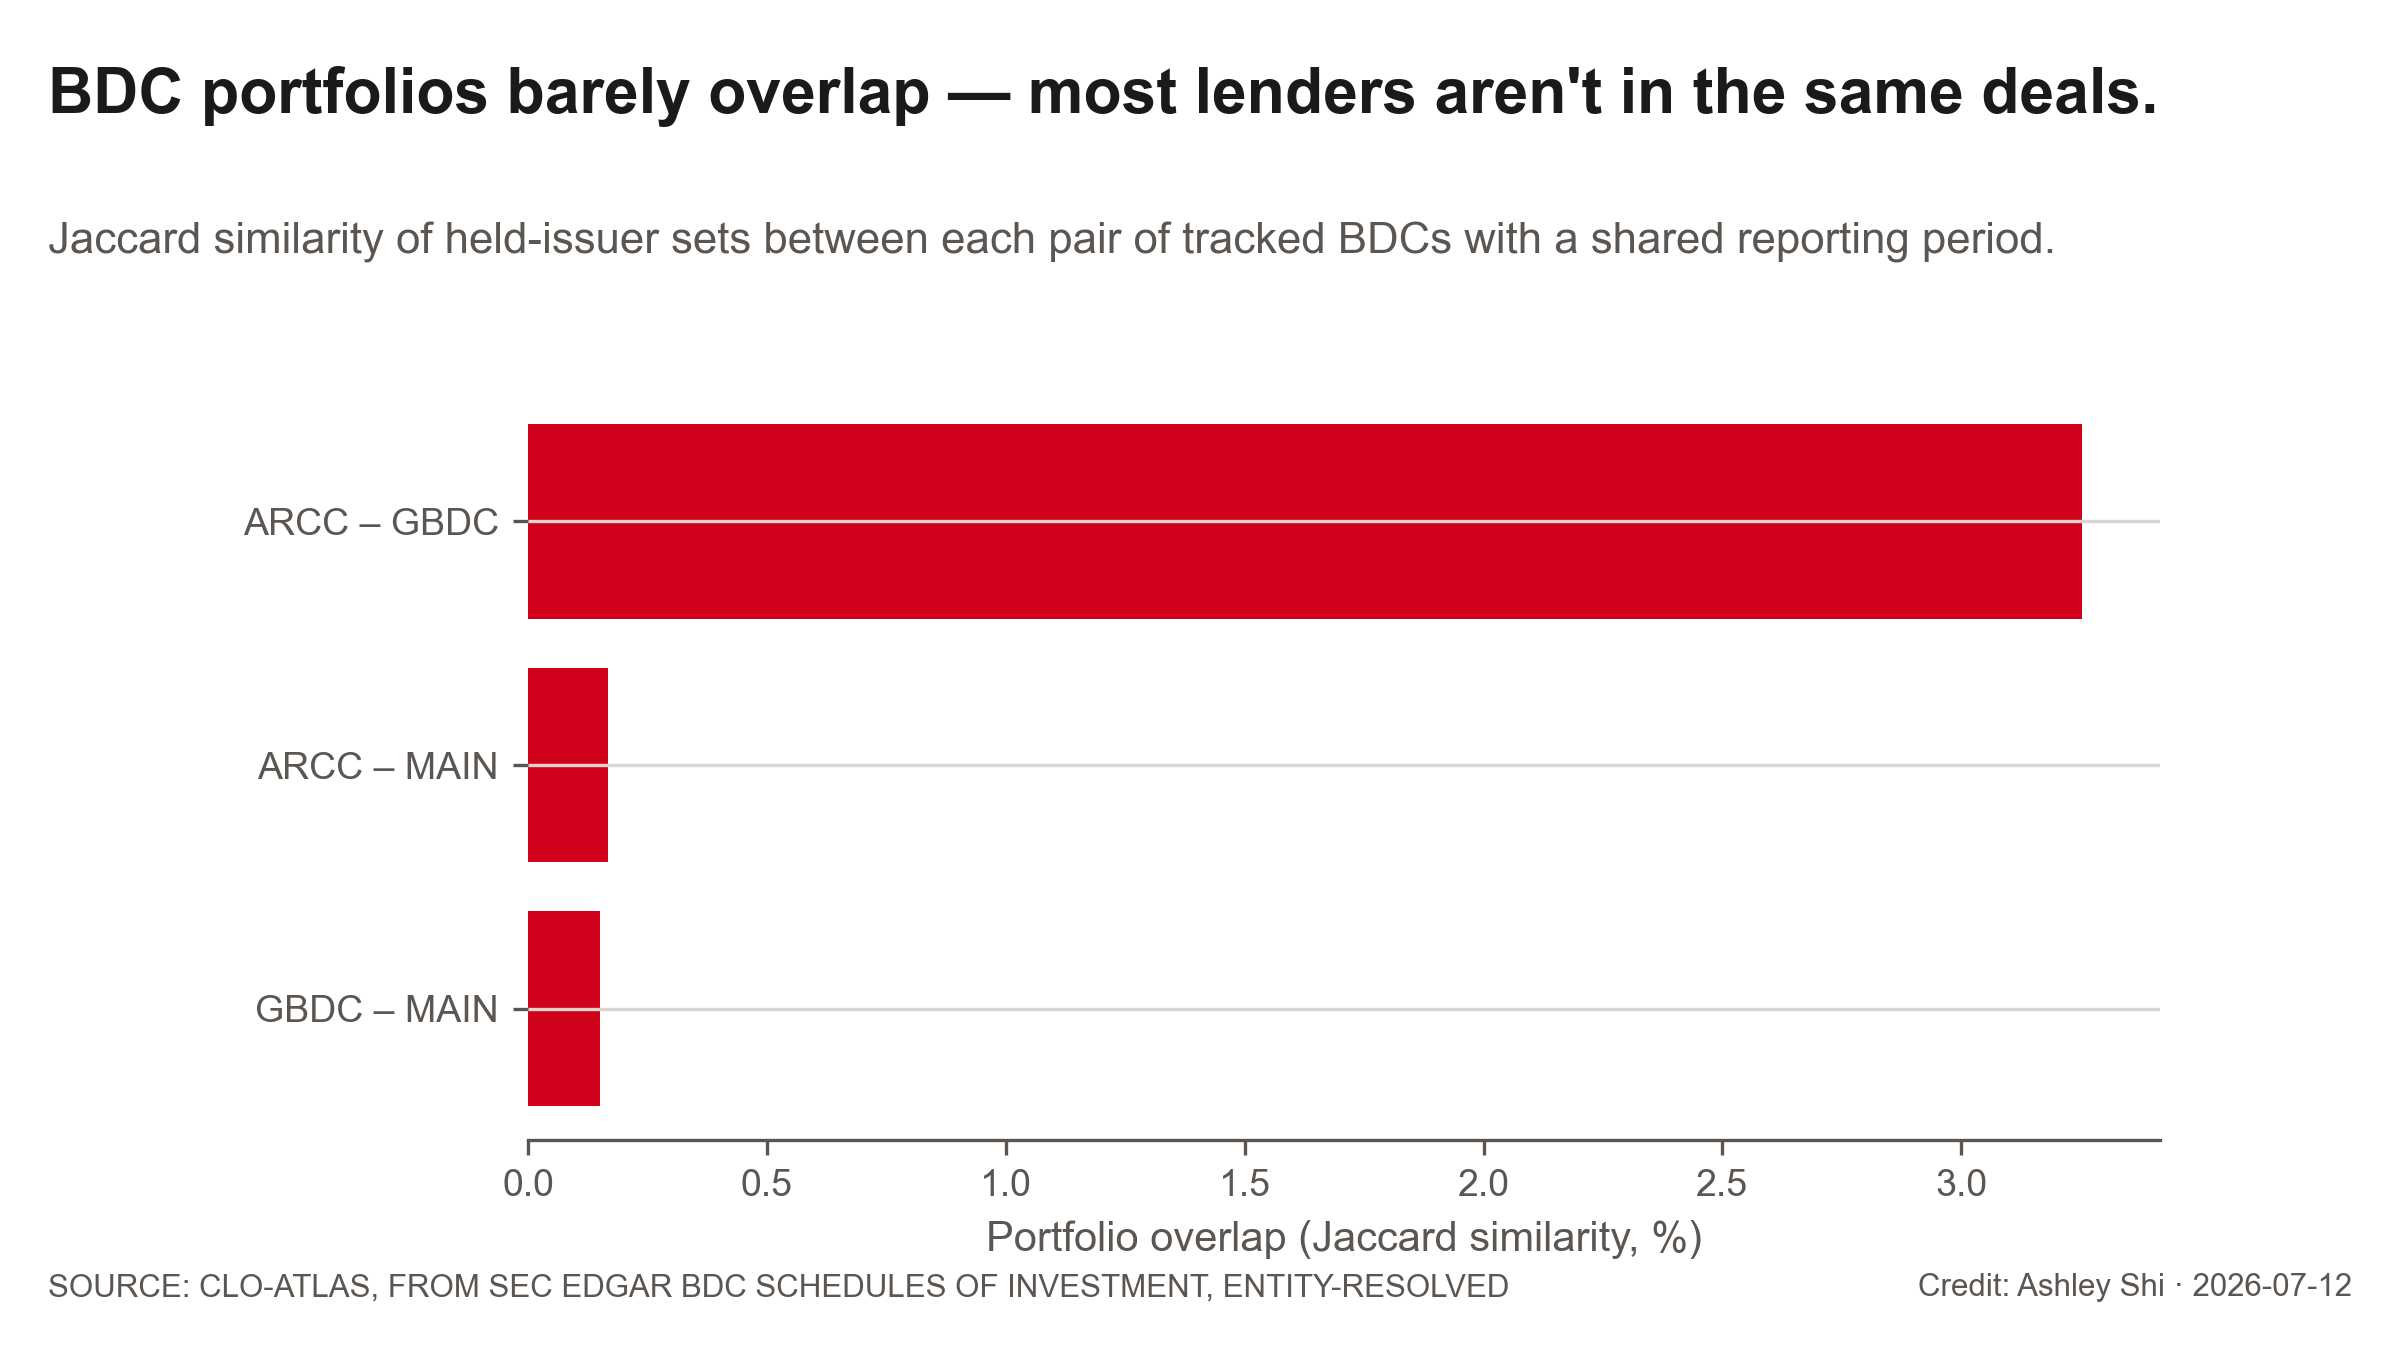

In [8]:
path = pathlib.Path("../figures") / "viz_bdc_overlap.png"
if path.exists():
    display(Image(filename=str(path)))
else:
    print(f"[skipped — not generated this run] viz_bdc_overlap")

### BDC portfolio overlap

**VERIFIED** — data: `analysis_crowding.py::bdc_overlap_jaccard()`, Jaccard similarity
of each pair of tracked BDCs' held-issuer sets in their most recent shared reporting
period (SEC EDGAR BDC Schedules of Investment, entity-resolved). Each bar is one BDC
pair; the x-axis is the share of their combined issuer sets that's actually held by
both. Overlap is low across the board — Ares Capital (ARCC) and Golub Capital BDC
(GBDC) share the most at roughly 3%, ARCC/Main Street Capital (MAIN) and GBDC/MAIN
share under 0.2%. Read alongside the crowded-issuers chart above, it sharpens the
concentration story rather than contradicting it: whole BDC portfolios are largely
distinct businesses, but the handful of names that do overlap are exactly the ones
worth watching, because they're the credits multiple lenders — and their downstream
CLOs — are simultaneously exposed to.


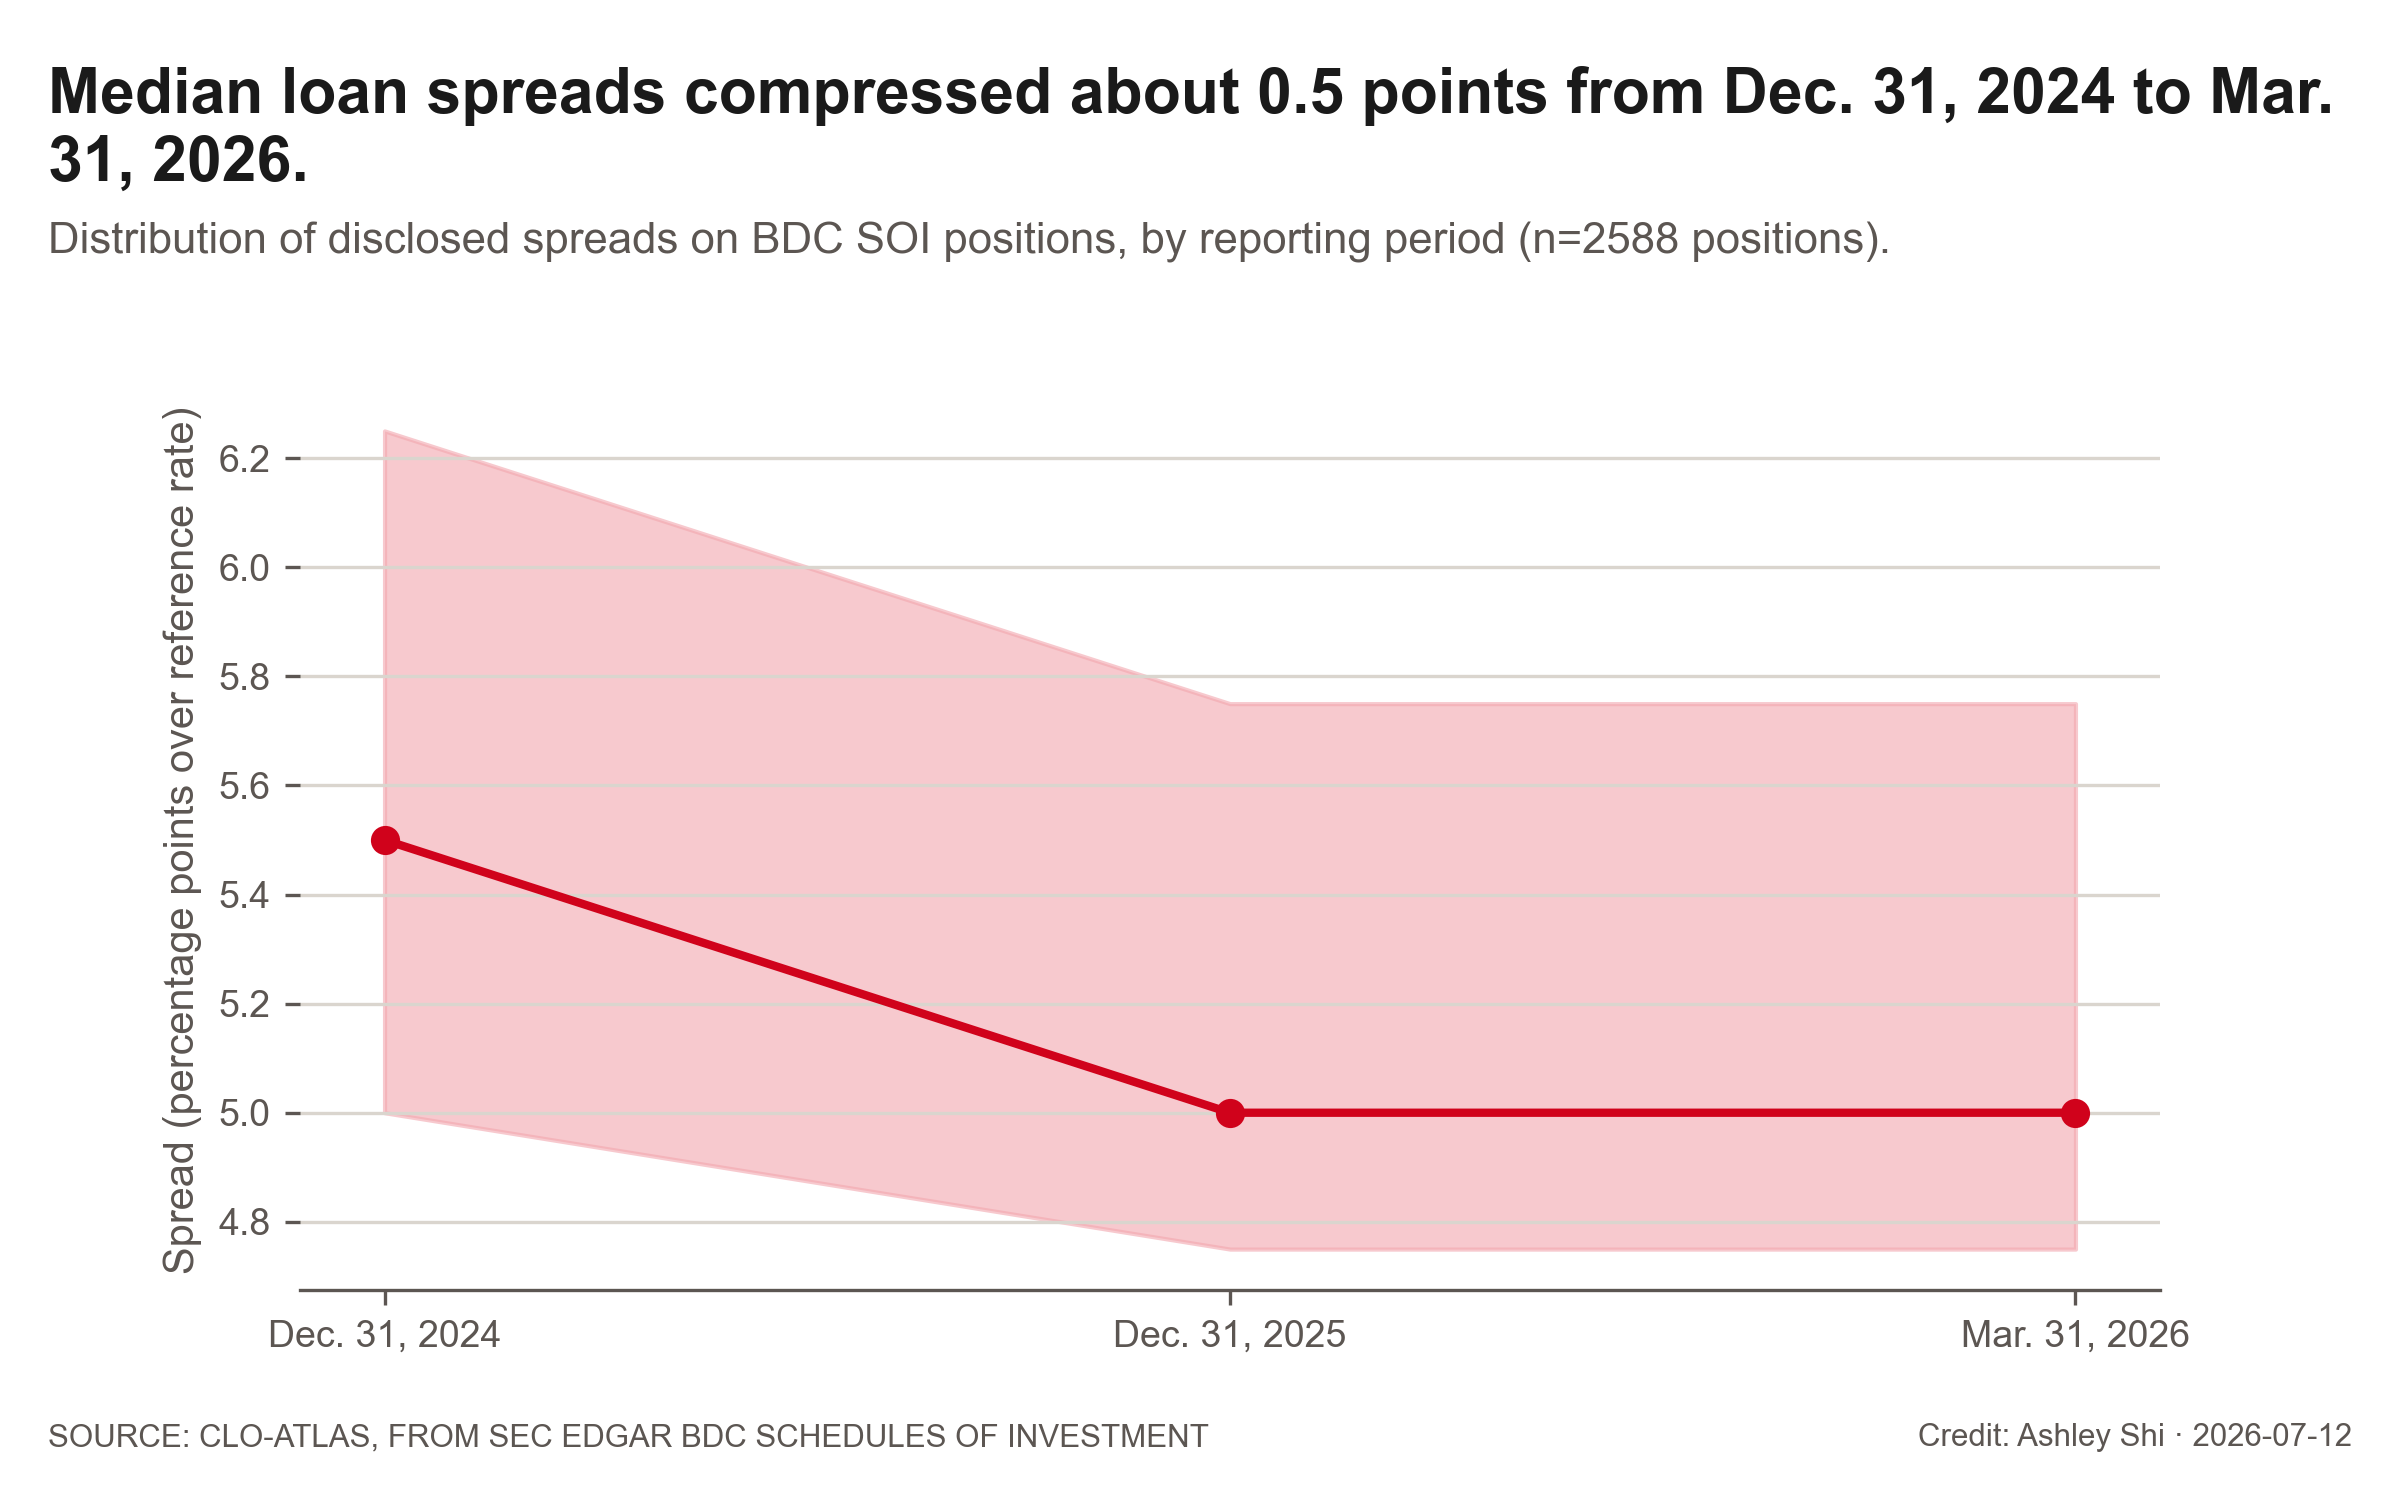

In [9]:
path = pathlib.Path("../figures") / "viz_spread_distribution.png"
if path.exists():
    display(Image(filename=str(path)))
else:
    print(f"[skipped — not generated this run] viz_spread_distribution")

### Spread compression over time

**VERIFIED** — data: `analysis_terms.py::spread_distribution_by_period()`, disclosed
coupon spreads on BDC SOI positions (SEC EDGAR BDC Schedules of Investment), grouped
by reporting period. The line is the median spread over the reference rate in
percentage points; the shaded band is the 25th–75th percentile range. Median spreads
compressed from 5.5 points (Dec. 2024, n=807 positions) to 5.0 points (Mar. 2026,
n=881 positions). That compression is the lender's side of the same trade CLO equity
and debt investors are on: tighter spreads mean less compensation per unit of credit
risk flowing into the loan pools that CLOs are assembled from, so this is direct
evidence of how loan-market pricing power has shifted over the period covered here.
